In [1]:
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

In [2]:
### Установим красивые дефолтные настройки
### Может быть лень постоянно прописывать
### У графиков параметры цвета, размера, шрифта
### Можно положить их в словарь дефолтных настроек

import matplotlib as mlp

mlp.rcParams['lines.linewidth'] = 5
mlp.rcParams['xtick.major.size'] = 20
mlp.rcParams['xtick.major.width'] = 5
mlp.rcParams['xtick.labelsize'] = 20
mlp.rcParams['xtick.color'] = '#FF5533'

mlp.rcParams['ytick.major.size'] = 20
mlp.rcParams['ytick.major.width'] = 5
mlp.rcParams['ytick.labelsize'] = 20
mlp.rcParams['ytick.color'] = '#FF5533'

mlp.rcParams['axes.labelsize'] = 20
mlp.rcParams['axes.titlesize'] = 20
mlp.rcParams['axes.titlecolor'] = '#00B050'
mlp.rcParams['axes.labelcolor'] = '#00B050'

In [4]:
import matplotlib.pyplot as plt

pd.options.display.max_columns = 500

In [9]:
from sklearn.datasets import make_moons

dataset = make_moons(n_samples=1000, noise=0.5, random_state=0)
dataset = pd.DataFrame(np.hstack((dataset[0], dataset[1].reshape(-1, 1))), columns=["x1", "x2", "y"])

dataset.head()

,x1,x2,y
0,2.216430,0.741684,1.0
1,2.057427,0.424853,1.0
2,-0.116847,0.004159,0.0
3,-0.710797,0.210482,1.0
4,0.267548,-0.460654,1.0


In [10]:
dataset.y.value_counts()

y
1.0    500
0.0    500
Name: count, dtype: int64

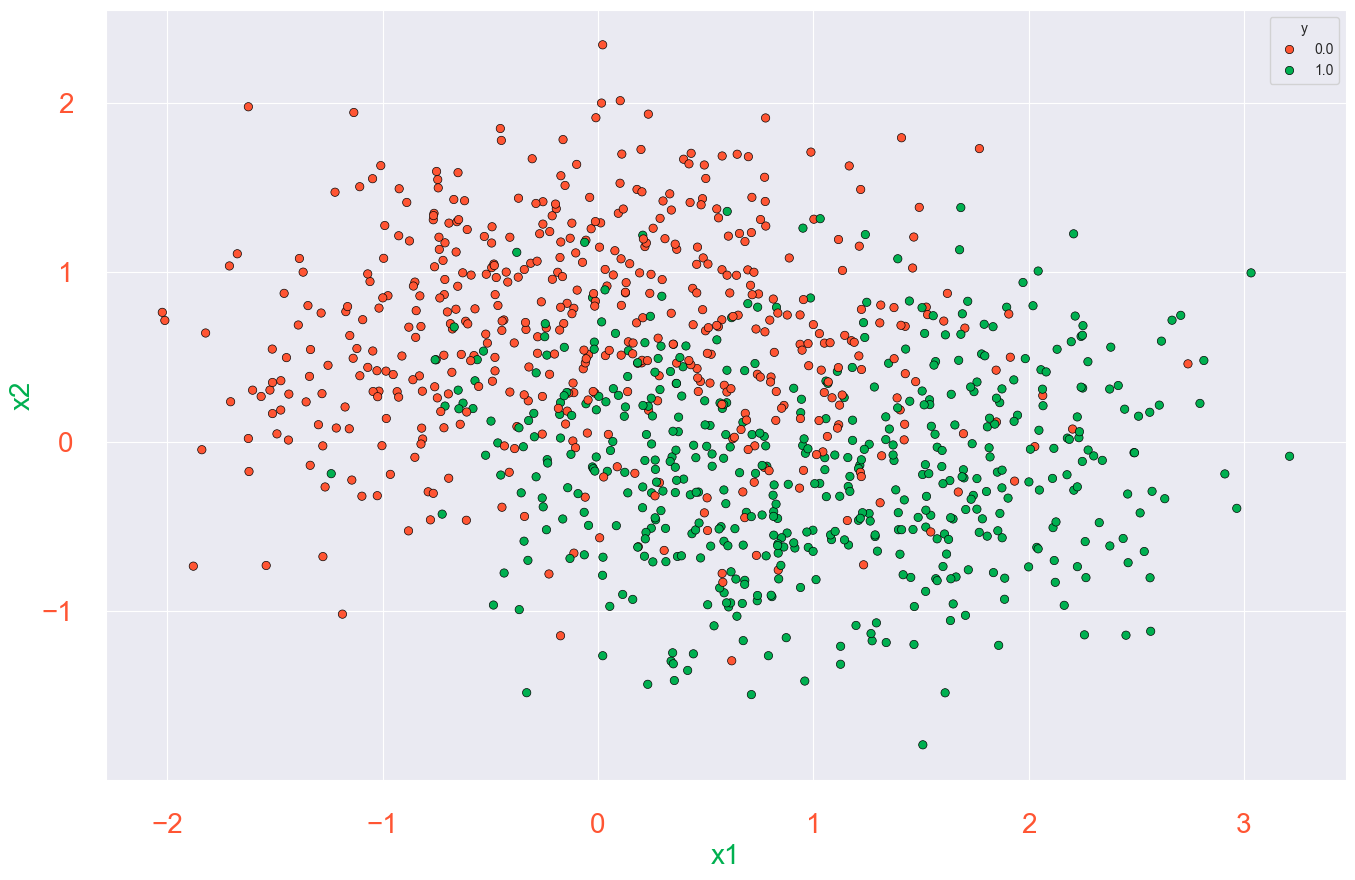

In [12]:
import seaborn as sns

fig = plt.figure()
fig.set_size_inches(16, 10)

sns.scatterplot(x="x1", y="x2", hue="y", edgecolor="k",
                palette=["#FF5533", "#00B050"],
                data=dataset)

plt.show()

In [13]:
from sklearn.tree import DecisionTreeClassifier

X = dataset.drop("y", axis=1)
Y = dataset["y"]

decision_tree = DecisionTreeClassifier()

decision_tree.fit(X, Y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
decision_tree.score(X, Y)

1.0

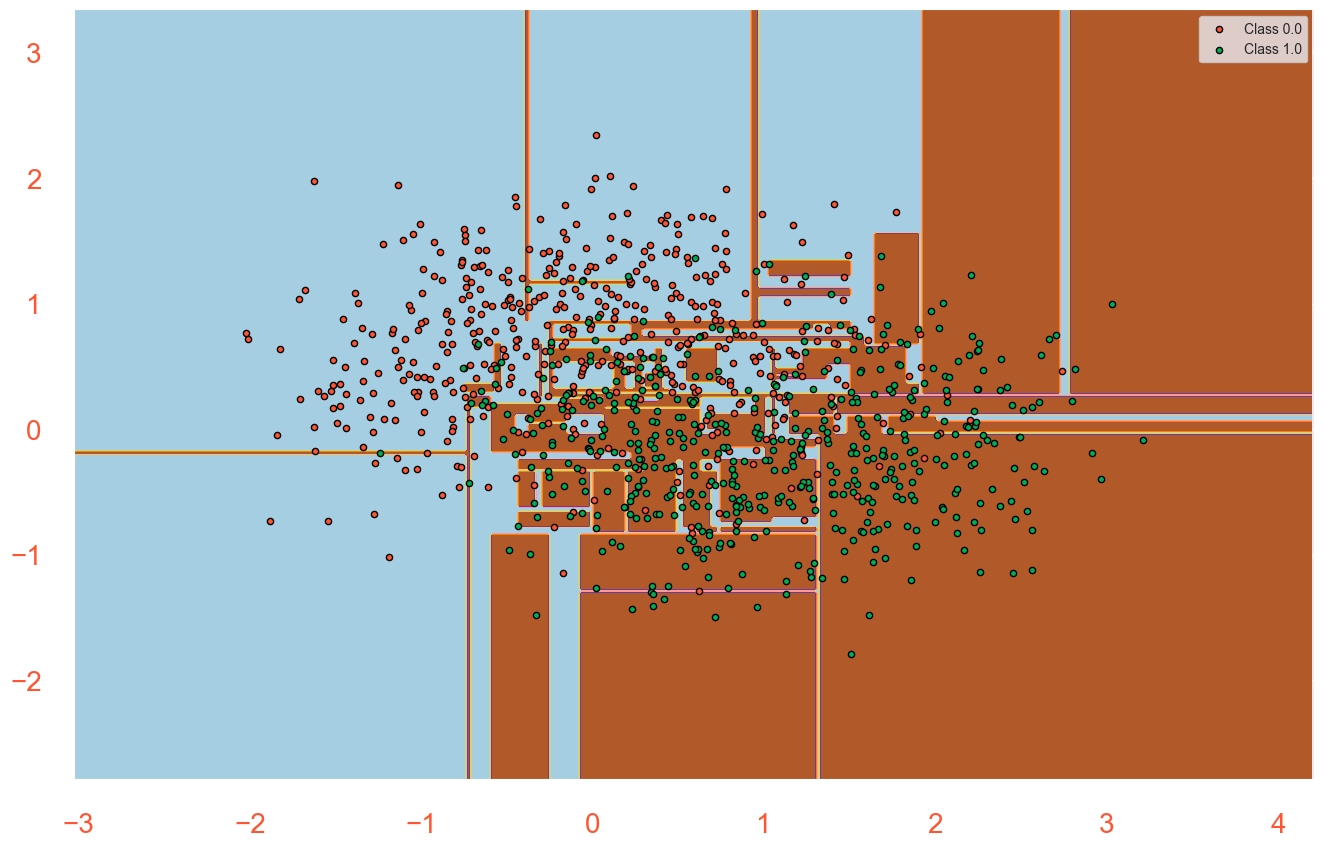

In [16]:
fig = plt.figure()
fig.set_size_inches(16, 10)

### Вычислим границы признакового пространства
pixel_step = 0.02

x1_min, x1_max = X.values[:, 0].min() - 1, X.values[:, 0].max() + 1
x2_min, x2_max = X.values[:, 1].min() - 1, X.values[:, 1].max() + 1

### Генерим много-много точек на плоскости
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, pixel_step),
                       np.arange(x2_min, x2_max, pixel_step))

Z = decision_tree.predict(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)

### Заполним пространство
cs = plt.contourf(xx1, xx2, Z, cmap=plt.cm.Paired)

plt.axis("tight")

for i, n, c in zip(range(2),decision_tree.classes_, ["#FF5533", "#00B050"]):
    idx = np.where(Y == i)
    plt.scatter(
        X.values[idx, 0],
        X.values[idx, 1],
        c=c,
        s=20,
        edgecolors="k",
        label="Class %s" %n,
    )
plt.xlim(x1_min, x1_max)
plt.ylim(x2_min, x2_max)
plt.legend(loc="upper right")

In [17]:
decision_tree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5)

decision_tree.fit(X, Y)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
decision_tree.score(X, Y)

0.842

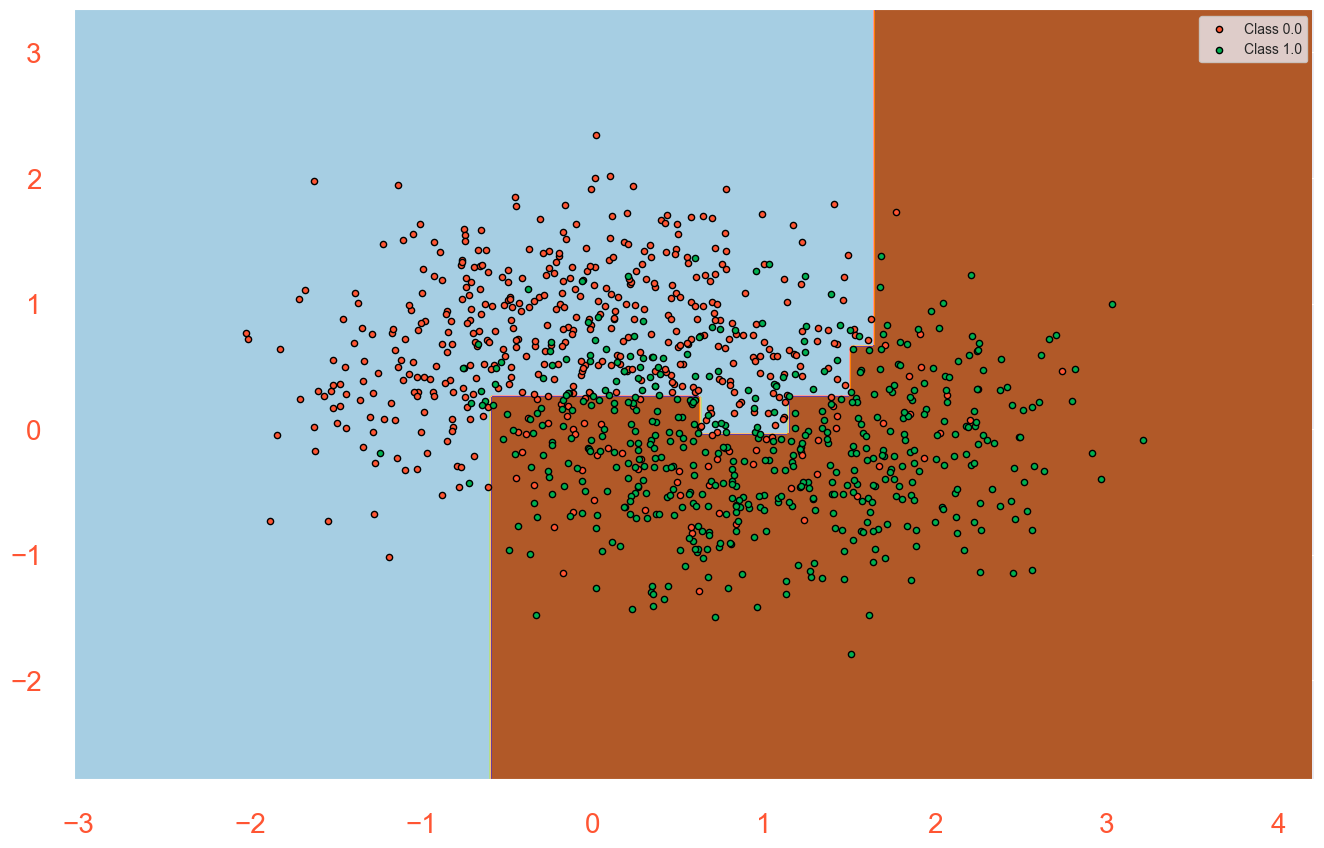

In [19]:
fig = plt.figure()
fig.set_size_inches(16, 10)

### Вычислим границы признакового пространства
pixel_step = 0.02

x1_min, x1_max = X.values[:, 0].min() - 1, X.values[:, 0].max() + 1
x2_min, x2_max = X.values[:, 1].min() - 1, X.values[:, 1].max() + 1

### Генерим много-много точек на плоскости
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, pixel_step),
                       np.arange(x2_min, x2_max, pixel_step))

Z = decision_tree.predict(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)

### Заполним пространство
cs = plt.contourf(xx1, xx2, Z, cmap=plt.cm.Paired)

plt.axis("tight")

for i, n, c in zip(range(2),decision_tree.classes_, ["#FF5533", "#00B050"]):
    idx = np.where(Y == i)
    plt.scatter(
        X.values[idx, 0],
        X.values[idx, 1],
        c=c,
        s=20,
        edgecolors="k",
        label="Class %s" %n,
    )
plt.xlim(x1_min, x1_max)
plt.ylim(x2_min, x2_max)
plt.legend(loc="upper right")

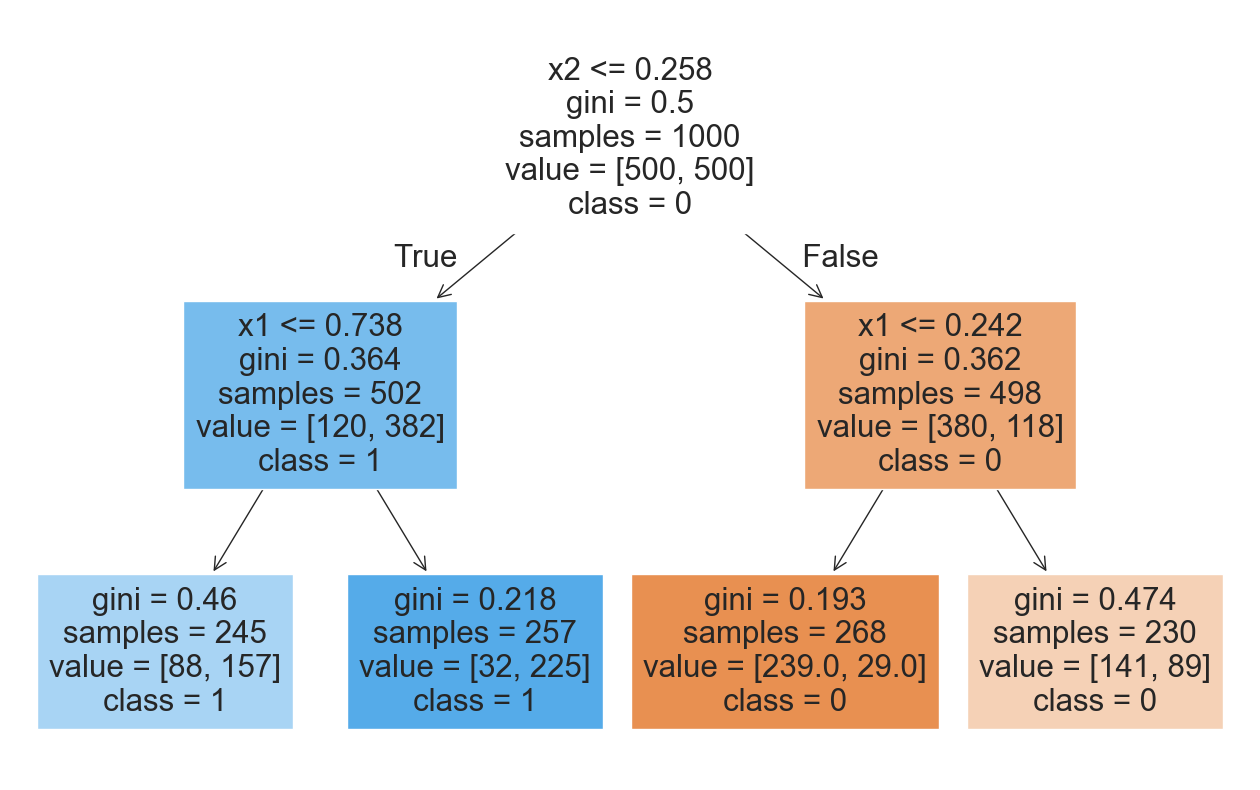

In [26]:
from sklearn import tree

decision_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=200)

decision_tree.fit(X, Y)

fig = plt.figure()
fig.set_size_inches(16, 10)

tree.plot_tree(decision_tree, feature_names=X.columns,
               class_names=decision_tree.classes_.astype(int).astype(str),
               filled=True)
plt.show()